In [33]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot

In [34]:
#from google.colab import drive
#drive.mount('/content/drive')

In [35]:
# Leer datos
data = pd.read_csv('ElectionData.csv')
# columnas numéricas útiles
#feature_cols = ["TimeElapsed","time","territoryName","totalMandates","availableMandates","numParishes","numParishesApproved","blankVotes","blankVotesPercentage","nullVotes","nullVotesPercentage","votersPercentage","subscribedVoters","totalVoters","pre.blankVotes","pre.blankVotesPercentage","pre.nullVotes","pre.nullVotesPercentage","pre.votersPercentage","pre.subscribedVoters","pre.totalVoters","Party","Mandates","Percentage","validVotesPercentage","Votes","Hondt","FinalMandates"]
feature_cols = ["TimeElapsed","totalMandates","availableMandates","numParishes","numParishesApproved","blankVotes","blankVotesPercentage","nullVotes","nullVotesPercentage","votersPercentage","subscribedVoters","totalVoters","pre.blankVotes","pre.blankVotesPercentage","pre.nullVotes","pre.nullVotesPercentage","pre.votersPercentage","pre.subscribedVoters","pre.totalVoters","Mandates","Percentage","validVotesPercentage","Votes","Hondt"]

target_col = "FinalMandates"

# limpiar filas con NaN
X = data[feature_cols].values
y = data[target_col].values
m = y.size

In [36]:
print(m)

21643


In [37]:
display(X[:6])

array([[0.00000e+00, 0.00000e+00, 2.26000e+02, 3.09200e+03, 1.08100e+03,
        9.65200e+03, 2.50000e+00, 8.87400e+03, 2.30000e+00, 5.13600e+01,
        7.52529e+05, 3.86497e+05, 8.31700e+03, 1.94000e+00, 8.17100e+03,
        1.91000e+00, 5.26600e+01, 8.13743e+05, 4.28546e+05, 0.00000e+00,
        3.82900e+01, 4.02200e+01, 1.47993e+05, 9.40000e+01],
       [0.00000e+00, 0.00000e+00, 2.26000e+02, 3.09200e+03, 1.08100e+03,
        9.65200e+03, 2.50000e+00, 8.87400e+03, 2.30000e+00, 5.13600e+01,
        7.52529e+05, 3.86497e+05, 8.31700e+03, 1.94000e+00, 8.17100e+03,
        1.91000e+00, 5.26600e+01, 8.13743e+05, 4.28546e+05, 0.00000e+00,
        3.32800e+01, 3.49500e+01, 1.28624e+05, 8.10000e+01],
       [0.00000e+00, 0.00000e+00, 2.26000e+02, 3.09200e+03, 1.08100e+03,
        9.65200e+03, 2.50000e+00, 8.87400e+03, 2.30000e+00, 5.13600e+01,
        7.52529e+05, 3.86497e+05, 8.31700e+03, 1.94000e+00, 8.17100e+03,
        1.91000e+00, 5.26600e+01, 8.13743e+05, 4.28546e+05, 0.00000e+00,
  

In [38]:
X.shape

(21643, 24)

In [39]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [40]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[0.00000e+00 0.00000e+00 2.26000e+02 ... 4.02200e+01 1.47993e+05
  9.40000e+01]
 [0.00000e+00 0.00000e+00 2.26000e+02 ... 3.49500e+01 1.28624e+05
  8.10000e+01]
 [0.00000e+00 0.00000e+00 2.26000e+02 ... 7.15000e+00 2.63070e+04
  1.60000e+01]
 ...
 [2.65000e+02 8.00000e+00 0.00000e+00 ... 1.50000e-01 2.56000e+02
  0.00000e+00]
 [2.65000e+02 8.00000e+00 0.00000e+00 ... 1.40000e-01 2.39000e+02
  0.00000e+00]
 [2.65000e+02 8.00000e+00 0.00000e+00 ... 7.00000e-02 1.18000e+02
  0.00000e+00]]
Media calculada: [1.33146052e+02 1.15447951e+01 1.14992838e+01 3.09956013e+02
 2.61090237e+02 8.87506667e+03 2.62162916e+00 6.14806875e+03
 1.96147115e+00 5.19837218e+01 6.27536748e+05 3.39074055e+05
 7.60800139e+03 2.07198494e+00 5.91462995e+03 1.77744213e+00
 5.45493721e+01 6.37850306e+05 3.59493176e+05 5.65494617e-01
 4.96848357e+00 5.20723236e+00 1.58520901e+04 1.12613778e+00]
Desviación estandar calculada: [7.76493990e+01 3.13138440e+01 3.17380502e+01 6.59040686e+02
 5.83363950e+02 2.14843777e+04 7

In [41]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro')
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

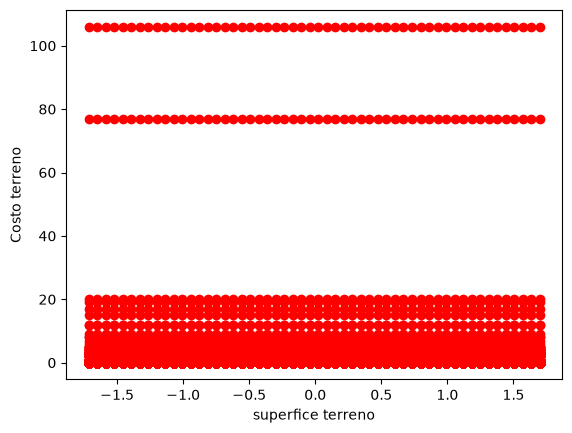

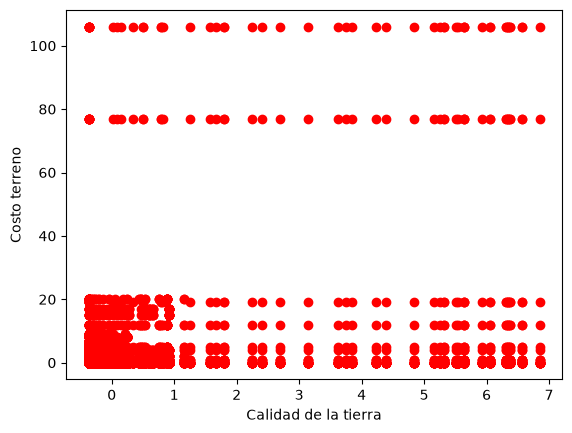

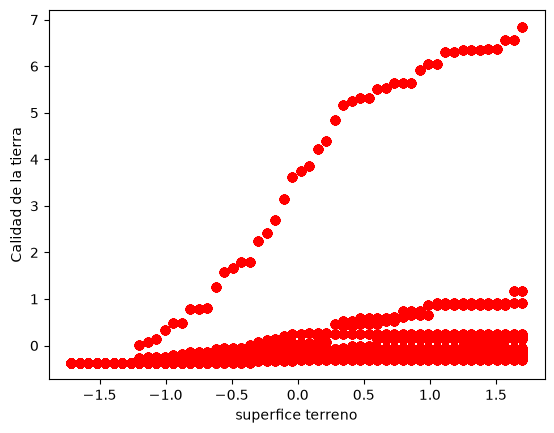

In [42]:
xlabel1 = "superfice terreno"
xlabel2 = "Calidad de la tierra"
ylabel1 = "Costo terreno"
graficarDatos(X_norm[:, 0], y, xlabel1, ylabel1)
graficarDatos(X_norm[:, 1], y, xlabel2, ylabel1)
graficarDatos(X_norm[:, 0], X_norm[:, 1], xlabel1, xlabel2)


In [43]:
# No olvidarse agregar unos a la matriz de x
#munos = np.ones([m, 1]).unsqueese
#print(munos.shape)
#X = np.stack([np.ones(m), X], axis=1)
#X = np.stack([X, munos], axis=1)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
# X = np.insert(X, 0, 1, axis=1)
# X.shape

In [44]:
X_ready

array([[ 1.        , -1.71470808, -0.36868023, ...,  3.21783195,
         1.4192844 , 14.75732693],
       [ 1.        , -1.71470808, -0.36868023, ...,  2.73349507,
         1.211248  , 12.69167309],
       [ 1.        , -1.71470808, -0.36868023, ...,  0.17854915,
         0.11229293,  2.36340389],
       ...,
       [ 1.        ,  1.69806785, -0.11320217, ..., -0.46478256,
        -0.16751275, -0.17893929],
       [ 1.        ,  1.69806785, -0.11320217, ..., -0.46570161,
        -0.16769534, -0.17893929],
       [ 1.        ,  1.69806785, -0.11320217, ..., -0.47213492,
        -0.16899497, -0.17893929]], shape=(21643, 25))

In [45]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  # h = np.dot(X, theta)
  # print(h)
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

In [46]:
theta = np.random.randn(X_ready.shape[1]) * 0.01
JJ = calcularCosto(X_ready, y, theta)
print(f"con theta:{ theta } se obtiene un costo de: {JJ}")

con theta:[ 3.10373085e-04 -1.83389290e-02 -3.93906532e-03 -1.78190183e-02
  1.20433717e-03  1.76492859e-02 -9.48317315e-03 -9.53126615e-03
  5.25829448e-03 -2.51464057e-04 -4.96826893e-03  1.39093497e-02
 -8.94813096e-03 -7.27018024e-03  3.34780371e-03 -1.02943978e-02
  8.80717710e-03  2.83093568e-03 -1.46297189e-02  1.27605969e-02
  1.53937941e-02  7.21776608e-03  2.60682175e-05  3.13337617e-02
  4.26352603e-03] se obtiene un costo de: 23.966659704091846


In [47]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
  m = y.shape[0]
  theta = theta.copy()
  J_historico = []

  for i in range(numero_iteraciones):
    theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
    J_historico.append(calcularCosto(X, y, theta))

  return theta, J_historico

los valores de theta calculados son: [ 1.12613778e+00 -1.68017242e-03 -4.96873016e-01 -1.00633411e-01
 -1.04345096e-01  8.63421401e-02  3.90415102e-02 -8.10381136e-05
  5.47878788e-02  1.75089557e-03  1.32120351e-03  3.35828456e-02
  6.44238334e-02  2.96282623e-02 -6.70824424e-03  5.29967217e-02
 -5.79556731e-03 -3.42569039e-03  3.76744746e-02  4.62240299e-02
  1.46233722e+00 -9.93301171e-02 -8.89459423e-02 -1.26100129e+00
  6.91702665e+00]
con un costo de: 0.1606247979272032 


Text(0, 0.5, 'Costo J')

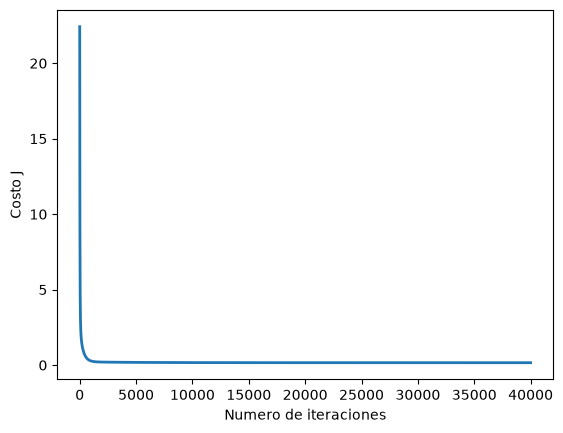

In [48]:
theta = np.random.randn(X_ready.shape[1]) * 0.01

num_ite = 40000
alpha = 0.01

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_ite)
print(f"los valores de theta calculados son: { theta }")
print(f"con un costo de: { J_historico[-2]} ")

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')


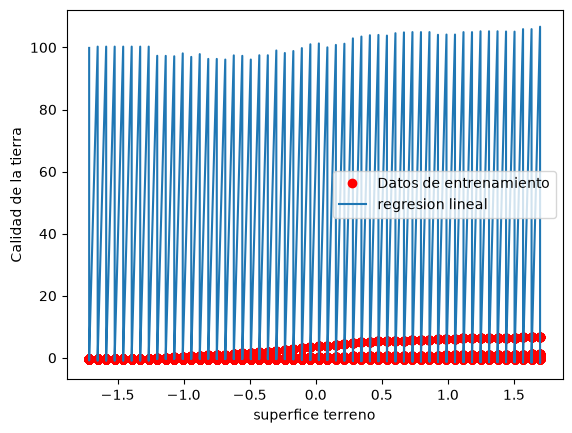

In [49]:
#graficarDatos(X[:, 1], y, xlabel1, ylabel1)
# graficarDatos(X[:, 2], y, xlabel2, ylabel1)
graficarDatos(X_ready[:, 1], X_ready[:, 2], xlabel1, xlabel2)

pyplot.plot(X_ready[:, 1], np.dot(X_ready, theta), '-')

pyplot.legend(['Datos de entrenamiento', 'regresion lineal'])

In [50]:
fila = X[0].copy()          # toma la primera fila de características
fila_norm = (fila - mu) / sigma
xp = np.concatenate([[1.0], fila_norm])

y_pred = np.dot(xp, theta)
print("Predicción con fila real:", y_pred)

Predicción con fila real: 99.84586255256528


In [51]:
#Utilizando la ecuacion de la normal

In [52]:
def calcularThethaEcuacionNormal(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)
    return theta

In [53]:
X_ren = np.concatenate([np.ones((m, 1)), X], axis=1)

In [54]:
theta = calcularThethaEcuacionNormal(X_ren, y);
print(f"los valores de theta calculados son: { theta }")


los valores de theta calculados son: [ 1.26377486e-01 -1.62436586e-05 -2.13882943e-02 -5.14534925e-03
  2.21619175e-05 -6.89381501e-06 -2.70489583e-07 -9.99927383e-03
 -5.64757650e-07  1.17337562e-03 -2.66406332e-03 -1.87187618e-07
  8.32849503e-07 -1.85604245e-06  7.41410431e-03  1.86222997e-07
 -1.34494480e-03  2.08772452e-03  1.28944477e-07 -2.30959635e-08
  3.37798155e-01 -5.45722178e-02  3.46900102e-02 -1.39844830e-05
  1.10081559e+00]


In [55]:
fila = X[0].copy()
print(fila)

[0.00000e+00 0.00000e+00 2.26000e+02 3.09200e+03 1.08100e+03 9.65200e+03
 2.50000e+00 8.87400e+03 2.30000e+00 5.13600e+01 7.52529e+05 3.86497e+05
 8.31700e+03 1.94000e+00 8.17100e+03 1.91000e+00 5.26600e+01 8.13743e+05
 4.28546e+05 0.00000e+00 3.82900e+01 4.02200e+01 1.47993e+05 9.40000e+01]


In [56]:
fila = X[0].copy()
fila_norm = (fila - mu) / sigma
xp = np.concatenate([[1.0], fila_norm])

price = np.dot(xp, theta)

print(f"Predicción para la primera fila: {price}")

Predicción para la primera fila: 16.237698599818305
